<a href="https://colab.research.google.com/github/gar-nov/tirocinio/blob/main/EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ANALISI ESPLORATIVA DEI DATI (EDA)
Dopo aver effettuato la pulizia dei dati sul dataset, passiamo all'analisi esplorativa dei dati. l'obiettivo principale di questa fase è comprendere meglio la struttura e le caratteristiche dei dati al fine di supportare le scelte future in fase di modellazione.
L'eda si concentrerà su:
- la verifica della qualità del dataset dopo la pulizia
- l'analisi della distribuzione delle classi target: benigno vs attacco
- esaminare la frequenza dei diversi tipi di attacco
- la visualizzazione delle distribuzioni numeriche e delle correlazioni tra feature

importazione librerie e caricamento dataset filtrato per l'EDA

In [ ]:
from google.colab import drive
drive.mount('/content/drive')






Mounted at /content/drive


In [ ]:
import pandas as pd

data = pd.read_csv('/content/drive/MyDrive/veremi_clean.csv')




importo le librerie per i dati e per la visualizzazione

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

# Struttura e qualità del dataset

vado ad esplorare la struttura generale del dataset per vedere se la pulizia dei dati è andata a buon fine

In [ ]:
# Informazioni generali: tipi colonna + valori non nulli
data.info()
# Statistiche sulle colonne numeriche
data.describe()
# Prime righe del dataset
data.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4844710 entries, 0 to 4844709
Data columns (total 11 columns):
 #   Column       Dtype  
---  ------       -----  
 0   rcvTime      float64
 1   pos_0        float64
 2   pos_1        float64
 3   spd_0        float64
 4   spd_1        float64
 5   acl_0        float64
 6   acl_1        float64
 7   hed_0        float64
 8   hed_1        float64
 9   attack       int64  
 10  attack_type  object 
dtypes: float64(9), int64(1), object(1)
memory usage: 406.6+ MB


,rcvTime,pos_0,pos_1,spd_0,spd_1,acl_0,acl_1,hed_0,hed_1,attack,attack_type
0,50831.914564,1288.736480,1059.729123,-16.287118,-2.921455,-0.055350,-0.009209,-0.998074,-0.062034,0,ConstPosOffset
1,26663.698218,498.583238,303.468778,13.394928,4.750152,-0.562873,-0.199565,0.950863,0.309613,0,ConstPosOffset
2,52161.314993,266.572055,41.134647,-0.531761,5.146397,-0.274390,2.655753,-0.095646,0.995415,0,ConstPosOffset
3,27659.392320,365.106961,257.518958,14.903867,5.368904,-0.080198,-0.028698,0.954075,0.299568,1,RandomPosOffset
4,25623.210073,347.726613,483.105599,-9.744141,-7.657281,0.310752,0.244477,-0.799141,-0.601144,0,EventualStop


come possiamo vedere dai risultati il dataset contiene 4.844.710 osservazioni e 11 colonne di cui:
- 9 variabili numeriche (float64)
- 1 variabile target attack (int64)
-1 variabile categorica attack type (object)

tutti i tipi di dato sono coerenti con le analisi che andremo a svolgere ed
inoltre nel dataset non sono presenti valori nulli quindi la pulizia dei dati è avvenuta correttamente

# l'analisi della distribuzione delle classi target: benigno vs attacco

Passiamo all'analisi della distribuzione delle classi target che rappresenta la classificazione dei messaggi come benigni (0) o malevoli(1)

Essa ci consente di:
- verificare la presenza di uno squilibrio tra le classi che potrebbe influenzare le prestazioni dei modelli di machine learning
- decidere se applicare tecniche di bilanciamento (es. oversampling, undersampling)

Conteggio assoluto delle classi:
attack
0    2695475
1    2149235
Name: count, dtype: int64

Distribuzione percentuale delle classi:
attack
0    55.64
1    44.36
Name: proportion, dtype: float64


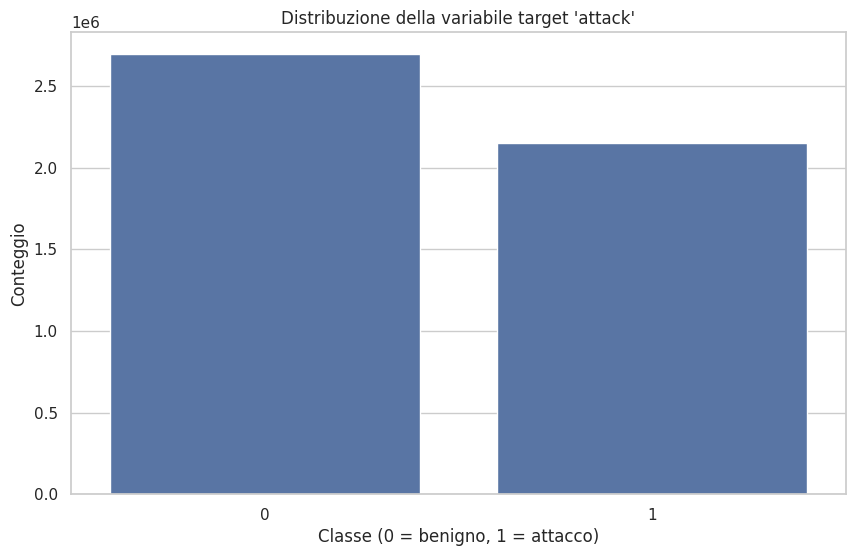

In [ ]:
# Conteggio assoluto delle classi target
print("Conteggio assoluto delle classi:")
print(data["attack"].value_counts())

# Percentuali delle classi
print("\nDistribuzione percentuale delle classi:")
print(data["attack"].value_counts(normalize=True).round(4) * 100)

# Visualizzazione grafica

sns.countplot(x="attack", data=data)
plt.title("Distribuzione della variabile target 'attack'")
plt.xlabel("Classe (0 = benigno, 1 = attacco)")
plt.ylabel("Conteggio")
plt.show()




la distribuzione delle classi target risulta abbastanza bilanciata:
- **55.64%** benigni
- **44.36%** attacchi

 non è quindi necessario applicare tecniche di bilanciamento (per ora)




In [ ]:
# Creo un campione dal dataset solo per i grafici
N = 300_000
df_plot = data.sample(n=min(N, len(data)), random_state=42)

print("Dimensioni del sample per i grafici:", df_plot.shape)


Dimensioni del sample per i grafici: (300000, 11)


### Analisi della distribuzione dei tipi di attacco

Il dataset include cinque scenari di attacco principali:
- **ConstPosOffset**  
- **RandomPosOffset**  
- **EventualStop**  
- **ConstPos**  
- **RandomPos**

vogliamo capire se la distribuzione dei tipi di attacco sia uniforme in modo tale da capire se il dataset possa introdurre bias in fase di addestramento


Conteggio assoluto per tipo di attacco:
attack_type
ConstPosOffset     968942
RandomPosOffset    968942
EventualStop       968942
ConstPos           968942
RandomPos          968942
Name: count, dtype: int64

Percentuali per tipo di attacco:
attack_type
ConstPosOffset     20.0
RandomPosOffset    20.0
EventualStop       20.0
ConstPos           20.0
RandomPos          20.0
Name: proportion, dtype: float64


/tmp/ipython-input-631369929.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x="attack_type", data=data, order=data["attack_type"].value_counts().index, palette="Set2")


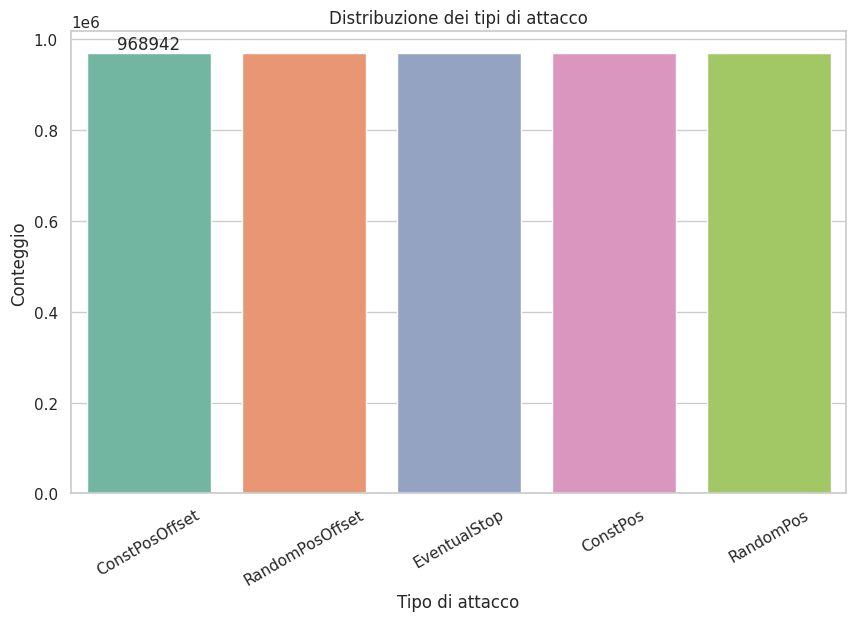

In [ ]:
print("Conteggio assoluto per tipo di attacco:")
print(data["attack_type"].value_counts())

print("\nPercentuali per tipo di attacco:")
print(data["attack_type"].value_counts(normalize=True).round(4) * 100)

plt.figure(figsize=(10,6))
ax = sns.countplot(x="attack_type", data=data, order=data["attack_type"].value_counts().index, palette="Set2")
ax.bar_label(ax.containers[0])  # numeri sopra le barre

plt.title("Distribuzione dei tipi di attacco")
plt.xlabel("Tipo di attacco")
plt.ylabel("Conteggio")
plt.xticks(rotation=30)
plt.show()




la distribuzione risulta perfettamente bilanciata e questo permetterà ai modelli di ml di apprendere in maniera equa tutte le tipologie di attacco

In [ ]:
pd.crosstab(data['attack_type'], data['attack'])


attack,0,1
attack_type,,
ConstPos,539095,429847
ConstPosOffset,539095,429847
EventualStop,539095,429847
RandomPos,539095,429847
RandomPosOffset,539095,429847


# Analisi delle feauture

Andiamo ad analizzare la distribuzione delle variabili numeriche per individuare pattern , valori anomali e differenze di scala



In [ ]:
num_cols = ["rcvTime","pos_0","pos_1","spd_0","spd_1","acl_0","acl_1","hed_0","hed_1"]

# Statistiche descrittive
stats = data[num_cols].describe().T.round(3)
display(stats)


,count,mean,std,min,25%,50%,75%,max
rcvTime,4844710.0,38054.326,12361.961,25208.812,27119.523,28518.604,51911.132,54180.335
pos_0,4844710.0,536.360,416.376,0.002,196.943,276.090,908.142,1502.747
pos_1,4844710.0,667.705,326.815,-7.283,386.975,728.217,916.694,1499.999
spd_0,4844710.0,-0.344,7.026,-18.584,-2.399,0.000,1.883,18.168
spd_1,4844710.0,0.317,7.871,-18.411,-4.257,0.000,4.922,17.940
acl_0,4844710.0,-0.002,0.875,-4.500,-0.155,0.000,0.133,4.504
acl_1,4844710.0,-0.018,1.166,-4.500,-0.208,0.000,0.206,4.505
hed_0,4844710.0,-0.065,0.636,-1.000,-0.623,-0.026,0.142,1.000
hed_1,4844710.0,0.037,0.768,-1.000,-0.837,0.065,0.966,1.000


Dalla tabella si osservano alcune caratteristiche importanti del dataset:

- **rcvTime**: il tempo di ricezione dei messaggi varia da circa 25.000 a 54.000 secondi, con una media di ~38.000.  
  È una variabile continua che cresce nel tempo, quindi non porta informazione diretta per la classificazione. è utile solo a livello esplorativo per descrivere il dataset, ma non verrà incluso come feature nel training dei modelli di classificazione.

- **pos_0 e pos_1**: rappresentano le coordinate spaziali. I valori si distribuiscono in un range di circa 0–1500,
  che corrisponde all’area simulata del traffico (scenario LuST).  

- **spd_0 e spd_1**: sono le componenti della velocità lungo gli assi. Hanno valori sia positivi che negativi
  (fino a ±18), con media vicina a 0. Questo indica che il dataset contiene movimenti in direzioni opposte
  (coerente con il traffico stradale).

- **acl_0 e acl_1**: accelerazioni lungo i due assi. I valori sono concentrati vicino allo zero con range ±4.5.  
  Questo è plausibile: la maggior parte dei veicoli accelera poco nella maggior parte del tempo.

- **hed_0 e hed_1**: componenti normalizzate del vettore di heading (direzione). Sono comprese tra -1 e 1,
  come ci si aspetta da un coseno/seno di un angolo di direzione.


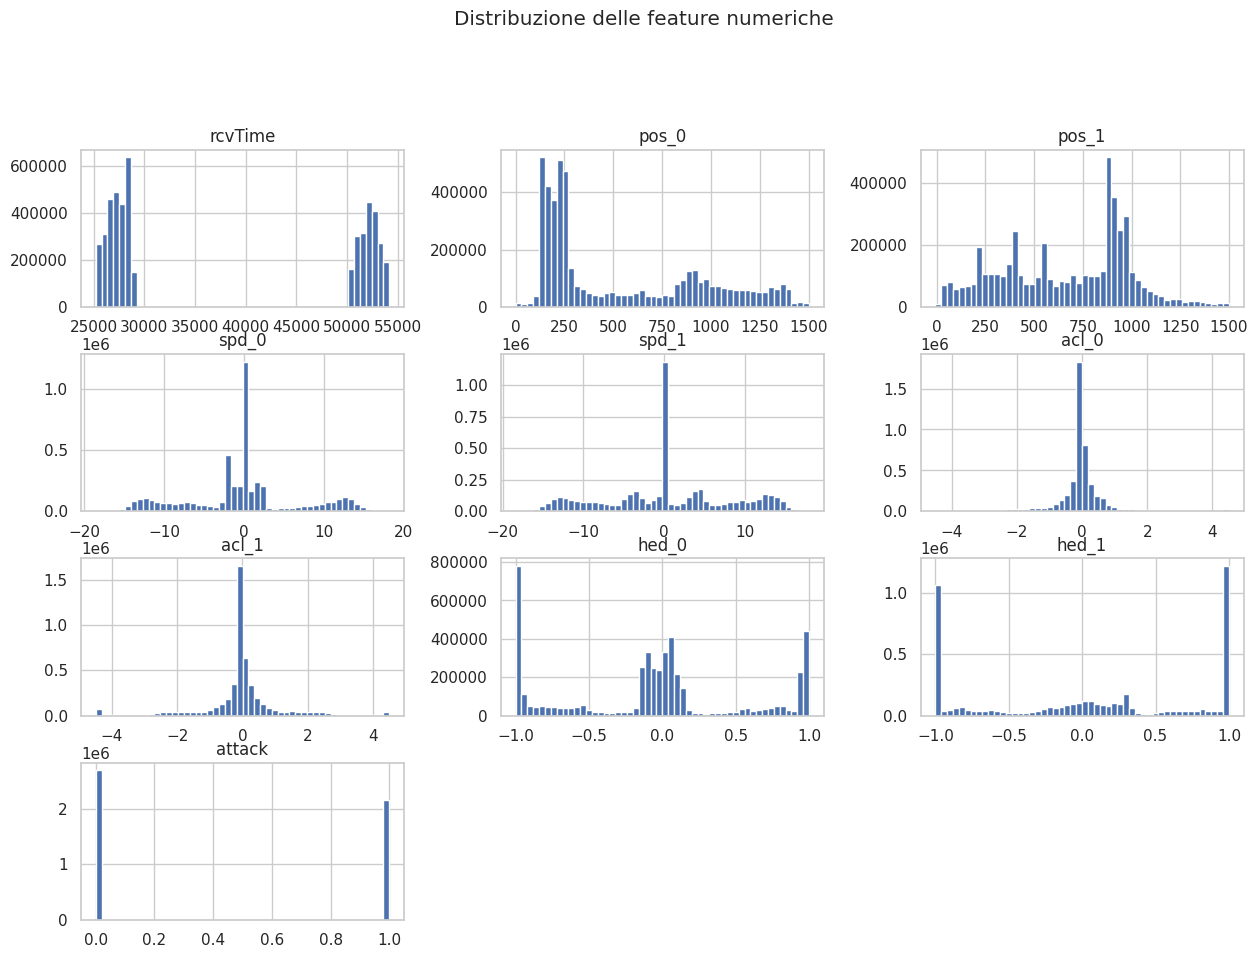

In [ ]:
# Istogrammi di tutte le feature numeriche
data.hist(bins=50, figsize=(15,10))
plt.suptitle("Distribuzione delle feature numeriche", y=1.02)
plt.show()


### Distribuzione delle feature numeriche

Gli istogrammi confermano le osservazioni fatte sulle statistiche descrittive:

- `rcvTime` mostra distribuzioni in blocchi separati, corrispondenti alle finestre temporali di simulazione. Come anticipato, non sarà usato come feature di classificazione.  
- `pos_0` e `pos_1` (coordinate spaziali) si distribuiscono in un range compreso tra 0 e ~1500, coerente con l’area simulata.  
- `spd_0` e `spd_1` (componenti di velocità) sono distribuite attorno a 0 con valori sia positivi che negativi (da -18 a +18), mostrando che i veicoli si muovono in direzioni opposte.  
- `acl_0` e `acl_1` (accelerazioni) hanno distribuzioni fortemente concentrate vicino allo zero, confermando che la maggior parte dei veicoli accelera poco.  
- `hed_0` e `hed_1` (heading normalizzato) si distribuiscono tra -1 e 1, come atteso per valori derivati da funzioni trigonometriche.  

Queste distribuzioni mostrano che i dati sono già in larga parte normalizzati attorno allo zero, ma le scale tra le variabili sono diverse (es. posizioni ~1500, velocità ~±20, heading ~±1). In fase di training potrà quindi essere utile applicare una **scalatura standard (StandardScaler)** per uniformare le feature.


# Analisi temporale con rcvTime

La variabile `rcvTime` indica il tempo della simulazione (secondi dall’inizio).  
Ad esempio, 25.000 secondi ≈ 07:00 del mattino.  

Nel dataset i valori appaiono in blocchi (25k–30k, 50k–54k) perché sono il risultato
di più finestre da 100 secondi ripetute in diversi scenari.  

 `rcvTime` è utile in EDA per mostrare la distribuzione temporale,
ma non verrà incluso come feature nei modelli di classificazione.


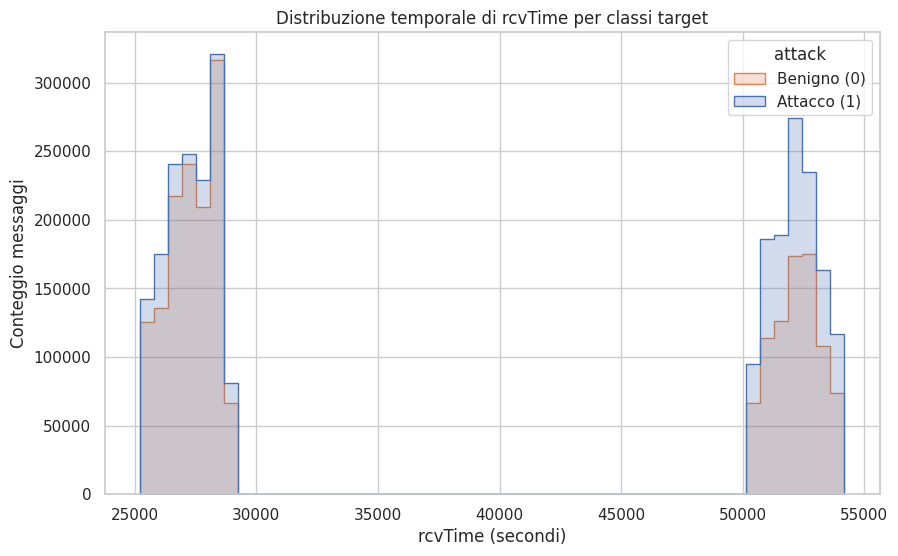

In [ ]:


sns.histplot(data=data, x="rcvTime", hue="attack", bins=50, element="step", stat="count")
plt.title("Distribuzione temporale di rcvTime per classi target")
plt.xlabel("rcvTime (secondi)")
plt.ylabel("Conteggio messaggi")
plt.legend(title="attack", labels=["Benigno (0)", "Attacco (1)"])
plt.show()







Il grafico mostra la distribuzione dei messaggi benigni e malevoli lungo il tempo di simulazione (`rcvTime`).  

Si osservano due blocchi principali di messaggi, che corrispondono a simulazioni diverse.  
All’interno di ciascun blocco, attacchi e messaggi benigni sono distribuiti in modo simile: non ci sono intervalli
in cui compaiono solo attacchi o solo messaggi corretti.  

 Questo conferma che `rcvTime` è utile solo a livello esplorativo per descrivere il dataset,
ma non verrà incluso come feature nel training dei modelli di classificazione.


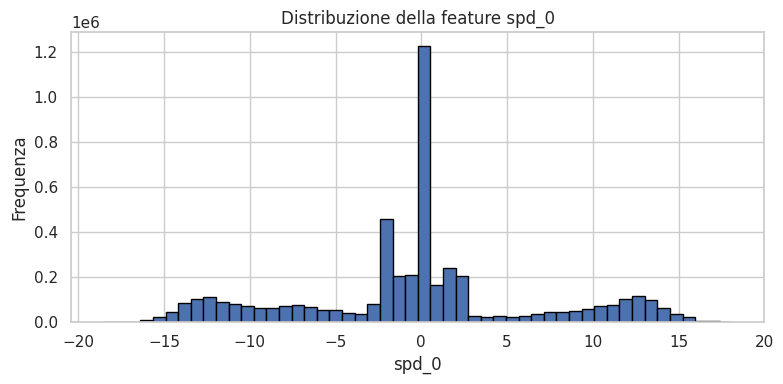

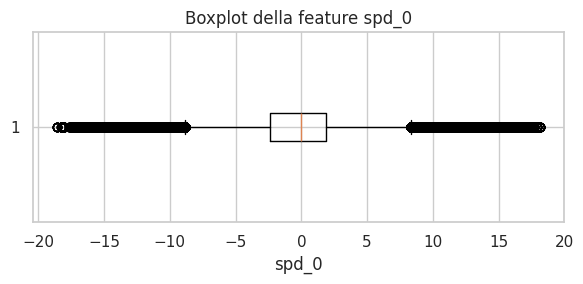

In [ ]:
#istogramma

plt.figure(figsize=(8,4))
plt.hist(data["spd_0"], bins=50, edgecolor="black")
plt.xlabel("spd_0")
plt.ylabel("Frequenza")
plt.title("Distribuzione della feature spd_0")
plt.tight_layout()
plt.show()

plt.figure(figsize=(6,3))
plt.boxplot(data["spd_0"], vert=False)
plt.xlabel("spd_0")
plt.title("Boxplot della feature spd_0")
plt.tight_layout()
plt.show()




L’istogramma mostra che la distribuzione di `spd_0` è fortemente concentrata su valori bassi: la maggior parte dei veicoli è ferma o si muove a velocità ridotta.  
Il boxplot evidenzia inoltre la presenza di alcuni valori molto elevati, che appaiono come **outlier**.  
Questi casi sono rari ma importanti, perché rappresentano situazioni anomale nel comportamento del veicolo.  
In sintesi, `spd_0` ha una distribuzione sbilanciata (coda a destra), con valori tipici vicini a zero e pochi punti estremi.


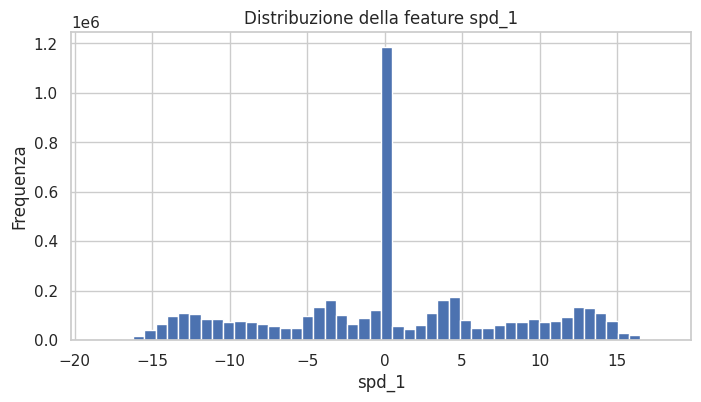

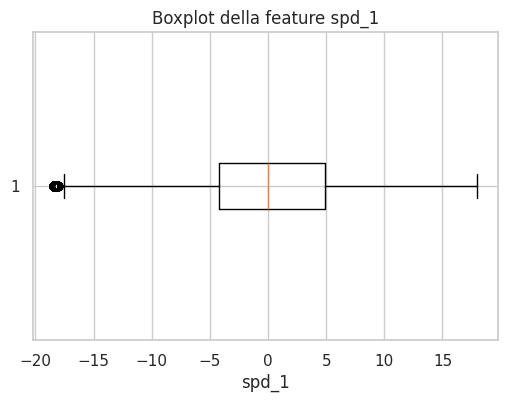

In [ ]:
data["spd_1"].hist(bins=50, figsize=(8,4))
plt.xlabel("spd_1")
plt.ylabel("Frequenza")
plt.title("Distribuzione della feature spd_1")
plt.show()

plt.figure(figsize=(6,4))
plt.boxplot(data["spd_1"], vert=False)
plt.xlabel("spd_1")
plt.title("Boxplot della feature spd_1")
plt.show()